---
title: "Observability in State Estimation"
description: "Use rank, topology, redundancy, and WLS experiments to understand observability."
author: "EulerLettersAI"
date: last-modified
jupyter: python3
format:
  html:
    code-fold: false
    code-links:
      - text: Download notebook
        icon: file-earmark-arrow-down
        href: 3.0-state-estimation-observability.ipynb?download=1
execute:
  echo: true
  warning: false
---

## Setup

This notebook requires Python 3.11 and the packages below. Run this command in a notebook cell once if they are not already installed:

```python
%pip install matplotlib==3.10.8 numpy==2.2.6 pandas==2.3.3 pandapower==3.2.1
```

Restart the kernel after installation, then run the notebook from top to bottom.

In [1]:
#| label: setup
#| echo: true

%matplotlib inline
import json
import logging
import warnings

import matplotlib.pyplot as plt
import networkx as nx
import numpy as np
import pandas as pd
import pandapower as pp
import pandapower.networks as pn
from pandapower.plotting import simple_plot

logging.getLogger("pandapower").setLevel(logging.WARNING)
warnings.filterwarnings("ignore", message=".*numba cannot be imported.*")
pd.options.display.float_format = "{:,.5f}".format

from pandapower.estimation import estimate

## Learning objectives

You will distinguish topological from numerical observability, test Jacobian rank, see why measurement location matters more than count, connect observability to a spanning tree, and observe WLS failure when the gain matrix is singular.

In [2]:
#| label: grid-builder
#| echo: true

def build_ieee_14_grid():
    # Load pandapower's built-in IEEE 14-bus benchmark without changing it.
    return pn.case14()


def draw_grid(net, title="The pandapower IEEE 14-bus grid"):
    # case14 includes geographic bus coordinates; simple_plot is a pandapower tool.
    ax = simple_plot(
        net, show_plot=False, bus_size=0.7, line_width=2.0,
        ext_grid_size=1.1, trafo_size=0.8, plot_loads=True,
        plot_gens=True, plot_sgens=True, load_size=0.8,
        gen_size=0.8, sgen_size=0.8,
    )
    for bus, row in net.bus.iterrows():
        point = json.loads(row.geo)["coordinates"]
        ax.annotate(f"Bus {bus + 1}", point, xytext=(7, 7),
                    textcoords="offset points", fontsize=10)
    ax.set_title(title)
    return ax

In [3]:
#| label: measurement-builder
#| echo: true

def add_redundant_measurements(net, seed=7):
    # Create reproducibly noisy, redundant SCADA-style measurements.
    rng = np.random.default_rng(seed)
    sigma_v, sigma_power = 0.005, 0.8

    # One voltage-magnitude measurement at every bus.
    for bus in net.bus.index:
        value = net.res_bus.at[bus, "vm_pu"] + rng.normal(0, sigma_v)
        pp.create_measurement(net, "v", "bus", value, sigma_v, bus,
                              name=f"V{bus}")

    # Active and reactive injection measurements at every bus.
    for bus in net.bus.index:
        for kind, column in [("p", "p_mw"), ("q", "q_mvar")]:
            value = net.res_bus.at[bus, column] + rng.normal(0, sigma_power)
            pp.create_measurement(net, kind, "bus", value, sigma_power, bus,
                                  name=f"{kind.upper()}{bus}_inj")

    # Active and reactive flow at every line's from end.
    for line in net.line.index:
        for kind, column in [("p", "p_from_mw"), ("q", "q_from_mvar")]:
            value = net.res_line.at[line, column] + rng.normal(0, sigma_power)
            pp.create_measurement(net, kind, "line", value, sigma_power,
                                  line, side="from",
                                  name=f"{kind.upper()}_{net.line.at[line, 'name']}_from")
    # Active and reactive flow at every transformer's high-voltage end.
    for trafo in net.trafo.index:
        for kind, column in [("p", "p_hv_mw"), ("q", "q_hv_mvar")]:
            value = net.res_trafo.at[trafo, column] + rng.normal(0, sigma_power)
            pp.create_measurement(net, kind, "trafo", value, sigma_power,
                                  trafo, side="hv",
                                  name=f"{kind.upper()}_T{trafo}_hv")
    return net

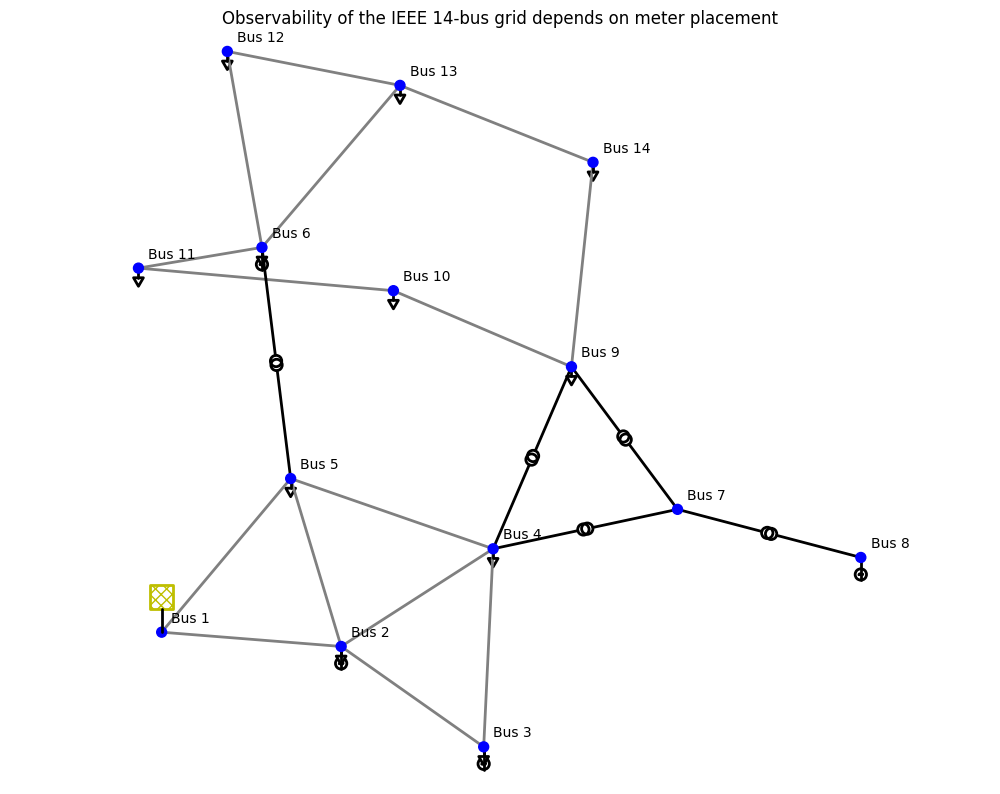

In [4]:
#| label: draw-grid
#| echo: true

net = build_ieee_14_grid()
draw_grid(net, "Observability of the IEEE 14-bus grid depends on meter placement")
plt.show()

## 1. The engineering question

Suppose communication failures remove some meters from the same IEEE 14-bus grid.

**Question.** Can the remaining measurements uniquely determine all bus-voltage magnitudes and non-reference angles? Which placements leave an unobservable island, how does redundancy improve resilience, and what symptom appears in a WLS estimator when observability is lost?

## 2. Local numerical observability

Linearize $z=h(x)+e$ near an operating point:

$$\Delta z\approx H\Delta x,
\qquad H=\left.\frac{\partial h}{\partial x}\right|_{x_0}.$$

With one reference angle removed, the AC state has $n_x=2n-1$ entries. It is locally observable if

$$\operatorname{rank}(H)=n_x.$$

Equivalently, for positive measurement weights, the gain matrix

$$G=H^TR^{-1}H$$

must be nonsingular. Merely having $m\ge n_x$ measurements is **necessary but not sufficient**: repeated measurements in one area cannot reveal an unmeasured island.

## 3. A transparent DC observability model

The full AC Jacobian contains both angle and magnitude sensitivities. To make placement visible, first use the DC approximation: $|V|\approx1$, resistance is neglected, and line $\ell=(i,j)$ has

$$P_{ij}\approx b_{ij}(\theta_i-\theta_j).$$

Set $\theta_0=0$. Each measured branch flow contributes a row to a reduced matrix $H_{\mathrm{DC}}$. The 13 unknown angles are observable exactly when that matrix has rank 13. Both transmission lines and transformers are branches. This angle-only demonstration is not a substitute for the final AC numerical check.

In [5]:
#| label: dc-rank-tests
#| echo: true

def branch_catalog(net):
    branches = []
    for idx, row in net.line.iterrows():
        branches.append((f"line {idx}", int(row.from_bus), int(row.to_bus)))
    for idx, row in net.trafo.iterrows():
        branches.append((f"trafo {idx}", int(row.hv_bus), int(row.lv_bus)))
    return branches

def flow_incidence_jacobian(net, measured_branches, reference_bus=0):
    nonref = [b for b in net.bus.index if b != reference_bus]
    column = {bus: k for k, bus in enumerate(nonref)}
    rows = []
    for _, from_bus, to_bus in measured_branches:
        row = np.zeros(len(nonref))
        if from_bus != reference_bus:
            row[column[from_bus]] += 1.0
        if to_bus != reference_bus:
            row[column[to_bus]] -= 1.0
        rows.append(row)
    return np.asarray(rows), nonref

branches = branch_catalog(net)
branch_graph = nx.Graph()
for branch in branches:
    branch_graph.add_edge(branch[1], branch[2], record=branch)
tree_graph = nx.minimum_spanning_tree(branch_graph)
tree_branches = [branch_graph[u][v]["record"] for u, v in tree_graph.edges]

placements = {
    "insufficient: one tree branch missing": tree_branches[:-1],
    "measured spanning tree": tree_branches,
    "redundant: all branches": branches,
}
rank_rows = []
for name, selected_branches in placements.items():
    H, unknown_buses = flow_incidence_jacobian(net, selected_branches)
    rank_rows.append({
        "placement": name, "measurements": H.shape[0],
        "unknown angles": H.shape[1], "rank": np.linalg.matrix_rank(H),
        "observable angles": np.linalg.matrix_rank(H) == H.shape[1],
    })
pd.DataFrame(rank_rows).set_index("placement")

,measurements,unknown angles,rank,observable angles
placement,,,,
insufficient: one tree branch missing,12,13,12,False
measured spanning tree,13,13,13,True
redundant: all branches,20,13,13,True


The first placement splits the measured graph into two components, leaving a relative angle shift invisible. A measured spanning tree connects every bus to the reference with 13 independent flow rows. Using all 20 branches adds loop measurements: they are redundant, yet valuable because suitable single-meter losses need not destroy observability.

In [6]:
#| label: unobservable-direction
#| echo: true

H_bad, buses = flow_incidence_jacobian(
    net, placements["insufficient: one tree branch missing"]
)
_, singular_values, vh = np.linalg.svd(H_bad, full_matrices=True)
null_direction = vh[-1]
pd.Series(null_direction, index=[f"theta_{b}" for b in buses],
          name="unobservable direction")

theta_1     0.00000
theta_2    -0.00000
theta_3     0.00000
theta_4     0.00000
theta_5     0.00000
theta_6    -0.00000
theta_7     1.00000
theta_8     0.00000
theta_9     0.00000
theta_10    0.00000
theta_11    0.00000
theta_12   -0.00000
theta_13    0.00000
Name: unobservable direction, dtype: float64

The null direction isolates the angle change that the selected meters cannot see. In larger systems, observability analysis similarly identifies unobservable islands and the pseudo-measurements or real meters needed to connect them.

## 4. AC WLS: observe the singular-gain symptom

    Now return to all 27 AC voltage states. Fourteen voltage-magnitude meters alone cannot determine any of the 13 unknown angles. pandapower’s WLS estimator therefore rejects the underobservable measurement set.

In [7]:
#| label: underobservable-wls
#| echo: true

pp.runpp(net, calculate_voltage_angles=True, numba=False)
truth = net.res_bus.copy()
for bus in net.bus.index:
    pp.create_measurement(net, "v", "bus", truth.at[bus, "vm_pu"],
                          0.005, bus, name=f"V{bus}")

try:
    underobservable = estimate(net, algorithm="wls", init="flat",
                               tolerance=1e-7, maximum_iterations=10)
except UserWarning as error:
    underobservable = {"success": False, "reason": str(error)}
print(f"Only voltage magnitudes ({len(net.measurement)} meters): {underobservable}")

ERROR:pandapower.estimation.state_estimation:System is not observable (cancelling)


ERROR:pandapower.estimation.state_estimation:Measurements available: 14. Measurements required: 27


Only voltage magnitudes (14 meters): {'success': False, 'reason': 'Measurements available: 14. Measurements required: 27'}


A failed estimate is a symptom, not a complete observability study: poor initialization or numerical conditioning can also prevent convergence. A production estimator performs observability analysis before estimation and reports unobservable islands.

## 5. Restore observability and redundancy

    Recreate the same IEEE case and the 82-measurement design from Notebook 2. The measurement Jacobian now covers magnitudes and angles across the whole network.

In [8]:
#| label: observable-wls
#| echo: true

net = build_ieee_14_grid()
pp.runpp(net, calculate_voltage_angles=True, numba=False)
add_redundant_measurements(net, seed=7)
redundant_result = estimate(net, algorithm="wls", init="flat",
                            tolerance=1e-7, maximum_iterations=50)
print(f"Redundant set ({len(net.measurement)} meters): {redundant_result}")
net.res_bus_est[["vm_pu", "va_degree"]]

Redundant set (82 meters): {'success': True, 'num_iterations': 5, 'objective_function_value': None, 'time': '2026-08-10 00:51:48'}


,vm_pu,va_degree
0,1.05540,0.00000
1,1.04078,-5.01639
2,1.00625,-12.82244
3,1.01426,-10.42095
4,1.01557,-8.85680
5,1.06606,-14.35326
6,1.06208,-13.54618
7,1.08796,-13.59177
8,1.06229,-15.16247
9,1.05391,-15.28203


## 6. Redundancy, critical measurements, and conditioning

Define the simple redundancy ratio

$$\rho=\frac{m}{n_x}.$$

Here $\rho=82/27$, but this number alone still does not prove observability. Placement controls rank. It is also useful to distinguish:

- **critical measurement:** removing it makes the system unobservable;
- **critical set:** removing a particular group makes the system unobservable;
- **numerical weakness:** $H$ has full rank but $G$ is ill-conditioned, so small meter errors can cause large state errors;
- **pseudo-measurement:** a forecast or historical estimate used with a relatively large $\sigma$, useful for restoring coverage without pretending it is a precise meter.

Singular values quantify numerical strength. If $H=U\Sigma V^T$, a very small $\sigma_{\min}(H)$ signals a nearly invisible state direction even when the formal rank is full.

In [9]:
#| label: conditioning
#| echo: true

H_tree, _ = flow_incidence_jacobian(net, placements["measured spanning tree"])
H_redundant, _ = flow_incidence_jacobian(net, placements["redundant: all branches"])
conditioning = pd.DataFrame({
    "smallest singular value": [
        np.linalg.svd(H_tree, compute_uv=False).min(),
        np.linalg.svd(H_redundant, compute_uv=False).min(),
    ],
    "condition number": [np.linalg.cond(H_tree), np.linalg.cond(H_redundant)],
}, index=["measured spanning tree", "all branch-flow meters"])
conditioning

,smallest singular value,condition number
measured spanning tree,0.26382,8.65900
all branch-flow meters,0.30140,8.41050


## 7. Practical observability workflow

1. Fix the reference angle and determine the state dimension.
2. Validate network topology and breaker status.
3. Build the measurement-to-state Jacobian for the available meters.
4. Test rank and partition any unobservable islands.
5. Add well-placed real meters or honest, low-weight pseudo-measurements.
6. Inspect singular values or gain-matrix conditioning, not rank alone.
7. Only then run WLS and bad-data analysis.

### Exercises

1. Remove a branch from `tree_branches`. Which buses form the unobservable component?
2. Remove each branch-flow row from `H_redundant` in turn. Which single losses preserve rank 13?
3. Give one transformer-flow meter ten times the standard deviation of other flow meters. How should its WLS influence change?
4. Why can a zero-injection bus act like a high-quality constraint, and why must its status be trusted?